# Testing the draft dot plots (`team/new_graphics/dotplot.py`)

This notebook exercises `make_dotplot()`, the draft implementation of the new
stacked dot plot type. It is **not** wired into `.plot()` yet — this is for
visually checking the draft before integration.

Every observation is one dot, drawn at its exact value on the x-axis; identical
values stack with **no gaps** — the first dot in each stack sits directly on the
number line and stacked dots touch. Values are **never binned**: the dot plot is
for discrete data. The y-axis stays honest: "Count" by default, "Relative
frequency" with `normalize=True`.

Colors are chosen automatically: the first batch on an axes is sky blue
(Okabe-Ito), and overlays cycle through the remaining Okabe-Ito hues (no black) —
students never pass a color.

(Continuous data — values that are all distinct — will eventually be routed to a
**rug plot** instead; that draft does not exist yet and is out of scope here.)

**How to run:** open this notebook from the `team/new_graphics/new_graphics_demos/`
folder using the `symbulate` conda environment, then run all cells.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook lives in <repo>/team/new_graphics/new_graphics_demos/.
REPO_ROOT = Path.cwd().parents[2]

# Make `import symbulate` find the dev copy in this repo, and
# `from dotplot import ...` find the draft module one folder up.
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "team" / "new_graphics"))

STYLE_PATH = REPO_ROOT / "symbulate" / "symbulate.mplstyle"
plt.style.use(str(STYLE_PATH))

from dotplot import make_dotplot

rng = np.random.default_rng(7)

## 1. Integer data: 30 rolls of a fair die

One stack per face. The bottom dot of every stack sits on the number line, stacked
dots touch, and the counts read straight off the y-axis ticks. Dots are capped at
12 points across (`DOTPLOT_MAX_DOT_SIZE`); because the dots must keep touching, the
y-axis extends past the tallest stack as needed to honor that cap. Sky blue is
picked automatically, the x-axis always reads "Value", and every plot carries
the same generic title, "Dot Plot".

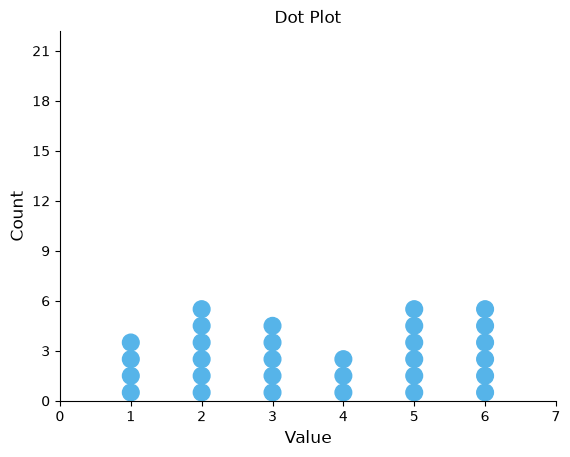

In [2]:
rolls = rng.integers(1, 7, 30)

ax = plt.gca()
make_dotplot(rolls, ax)
plt.show()

## 2. `normalize=True`: relative frequencies

Same picture, but each count is divided by the number of observations, so the y-axis
reads "Relative frequency". Useful for comparing batches of different sizes.

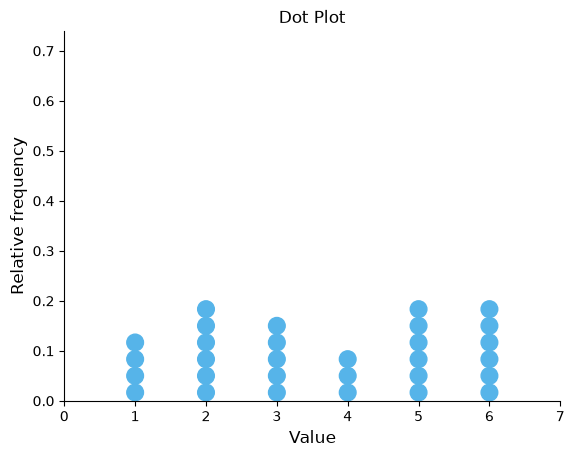

In [3]:
ax = plt.gca()
make_dotplot(rolls, ax, normalize=True)
plt.show()

## 3. Overlay — dodged lanes + tile-style boundary lines

A second `make_dotplot` call on the same axes draws each batch side by side around
the shared values. Because dodged dots no longer sit exactly on their value, light
**boundary lines appear halfway between neighboring stacks** (1.5, 2.5, ... here) so
every dot between 1.5 and 2.5 clearly belongs to 2 — the tile-plot-style guides
requested for exactly this case. A legend appears automatically in the top right,
defaulting to "Variable 1", "Variable 2" (override with `label=`), and the second
batch automatically gets the next Okabe-Ito hue — no colors passed anywhere.

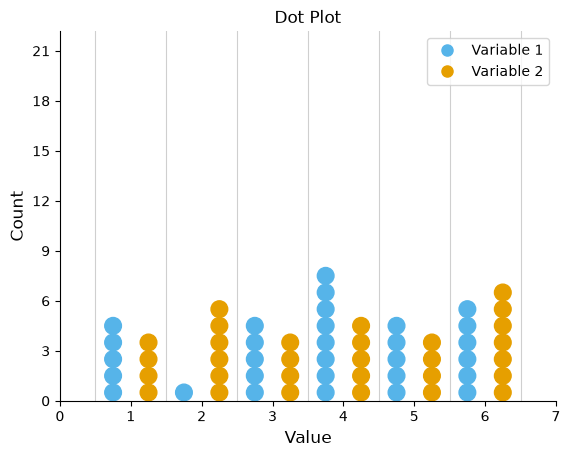

In [4]:
player_a = rng.integers(1, 7, 30)
player_b = rng.integers(1, 7, 30)

ax = plt.gca()
make_dotplot(player_a, ax)
make_dotplot(player_b, ax)
plt.show()

## 4. With real symbulate simulation data

The same prototype, but the data comes from an actual `RV(...).sim(...)` call instead
of raw numpy: the sum of two dice, simulated 40 times (`n <= 40` is the regime where
the lookup table will select the dot plot by default).

Caveat while testing today: creating `RVResults` currently calls `init_color()`,
which resets the color cycle to tab10 (removed in Phase 2), so we re-apply the
style *after* simulating.

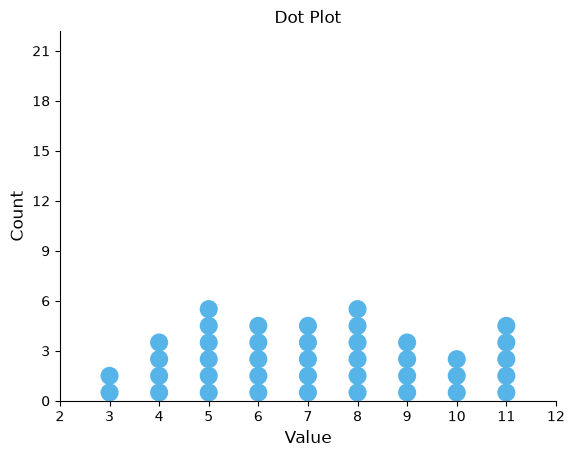

In [5]:
from symbulate import RV, BoxModel

die = list(range(1, 7))
roll_two = RV(BoxModel(die, size=2), sum)
sims = roll_two.sim(40)

plt.style.use(STYLE_PATH)  # re-apply: RVResults resets the color cycle to tab10

ax = plt.gca()
make_dotplot(np.asarray(list(sims)), ax)
plt.show()

## 5. Student-friendly messages

What a student sees when something is off: non-numeric data gets an explanation and a
suggestion (never a raw traceback), and mixing `normalize=` settings in one overlay
prints a note instead of silently drawing two incomparable y-scales.

In [6]:
try:
    make_dotplot(["H", "T", "H"], plt.gca())
except TypeError as err:
    print(err)
plt.close()

A dot plot needs numbers, but these values are not numeric (for example, text like 'H' or 'T'). Try .tabulate() to count how often each value occurs instead.


The dot plot already on these axes shows counts, so the new dots are shown as counts too. To switch, redraw all the dot plots in a fresh cell with the same normalize= setting.


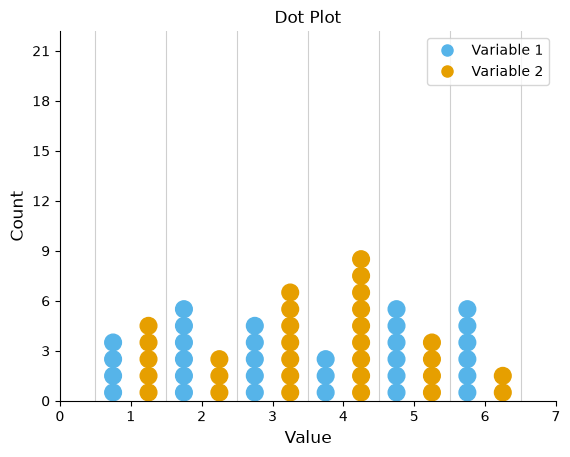

In [7]:
ax = plt.gca()
make_dotplot(rolls, ax)
make_dotplot(rng.integers(1, 7, 30), ax, normalize=True)
plt.show()

## Verification checklist

- [ ] Stacked dots touch — no vertical gaps — and the bottom dot sits on the number line
- [ ] Every stack sits at an exact data value — no binning anywhere
- [ ] Dots never grow past 12 points across, even for short stacks
- [ ] Colors are automatic: sky blue first, then the other Okabe-Ito hues for overlays
- [ ] Section 1: one stack per die face; y-axis counts match the tick marks
- [ ] Section 2: `normalize=True` switches the y-axis to "Relative frequency"
- [ ] Section 3: overlaid batches dodge side by side; boundary lines at 1.5, 2.5, ...; legend defaults to "Variable 1", "Variable 2"
- [ ] No gridlines; title reads "Dot Plot"; x-axis reads "Value"; no top/right spines
- [ ] Section 5: error and mismatch messages are understandable without knowing Python